In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

## Comparison of baselines

In [ ]:


def plot_scheduler_radar(data, title="Radar Plot"):
    """
    Radar chart with styling:
      - 'carbon only (best val)' -> solid red, thicker line
      - 'waittime only (best val)' -> solid blue, thicker line
      - all others -> dashed (striped) lines with distinct colors
    """

    # Metrics to plot
    metrics = [
        "Avg Wait", "Max Wait", "Avg Response",
        "Avg Slowdown", "System Utilization", "Carbon Emissions"
    ]
    num_vars = len(metrics)

    # Define which metrics are inverted (lower is better -> higher is better)
    invert_metrics = {"Avg Wait", "Max Wait", "Avg Response",
                      "Avg Slowdown", "Carbon Emissions"}

    # Collect raw values
    all_values = {m: [float(algo[m]) for algo in data.values()] for m in metrics}
    mins = {m: min(v) for m, v in all_values.items()}
    maxs = {m: max(v) for m, v in all_values.items()}

    # Angles for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    # Line widths
    other_lw = 2.0
    special_lw = other_lw + 0.5  # 0.5 px wider for highlighted lines

    # Special styles for the two highlighted algorithms
    special_styles = {
        "carbon only (best val)": {"color": "red",  "linestyle": "-", "linewidth": special_lw, "zorder": 5},
        "waittime only (best val)": {"color": "blue", "linestyle": "-", "linewidth": special_lw, "zorder": 5},
    }

    # Colors for other algorithms (avoid red/blue), plus dashed linestyles
    other_colors = cycle([
        "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b",
        "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
    ])
    dashed_styles = cycle([
        "--", ":", "-.", (0, (3, 2)), (0, (5, 2)), (0, (1, 2))
    ])

    # Plot each algorithm (lines only, no fill)
    for algo, values in data.items():
        stats = []
        for m in metrics:
            raw_val = float(values[m])
            if maxs[m] > mins[m]:
                norm_val = (raw_val - mins[m]) / (maxs[m] - mins[m])
            else:
                norm_val = 0.5
            if m in invert_metrics:
                norm_val = 1 - norm_val
            stats.append(norm_val)
        stats += stats[:1]  # close loop

        style = special_styles.get(algo)
        if style is None:
            color = next(other_colors)
            ls = next(dashed_styles)
            ax.plot(
                angles, stats,
                color=color,
                linestyle=ls,
                linewidth=other_lw,
                label=algo,
                alpha=0.95,
                zorder=3
            )
        else:
            ax.plot(
                angles, stats,
                color=style["color"],
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                label=algo,
                alpha=1.0,
                zorder=style["zorder"]
            )

    # Axis labels and cosmetics
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_rlabel_position(0)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(alpha=0.3)

    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


In [16]:
## Global cutoff
batch_baselines_val_results = {'FCFS Baseline': {'Validation Reward': 18.841868820294778,
  'Avg Wait': 6241.402740396379,
  'Max Wait': 533605.0,
  'Avg Response': 10793.021531685834,
  'Avg Slowdown': 177.4515107448421,
  'Episode Duration': 7837750.0,
  'Carbon Emissions': 28091754.682081796,
  'Weighted Carbon Emissions': -28091754.682081796,
  'System Utilization': 0.5823901774464929,
  'Action Analysis': {'Total Actions': 23851,
   'Schedule Action Percentage': 34.271099744245525,
   'Fixed Delay Percentage': 0.1383589786591757,
   'Wait Delay Percentage': 65.5905412770953,
   'Fixed Delays': {'300s': 33},
   'Wait for Jobs': {'1 jobs': 15644}}},
 '10-percentile Baseline': {'Validation Reward': -171.50457768119057,
  'Avg Wait': 9539418.495595792,
  'Max Wait': 14733166.0,
  'Avg Response': 9543970.11438708,
  'Avg Slowdown': 444994.60472693114,
  'Episode Duration': 21832274.0,
  'Carbon Emissions': 19264189.91778237,
  'Weighted Carbon Emissions': -19264189.91778237,
  'System Utilization': 0.20907710361647394,
  'Action Analysis': {'Total Actions': 82294,
   'Schedule Action Percentage': 9.932680389821858,
   'Fixed Delay Percentage': 80.30354582351083,
   'Wait Delay Percentage': 9.763773786667315,
   'Fixed Delays': {'300s': 66085},
   'Wait for Jobs': {'1 jobs': 8035}}},
 '25-percentile Baseline': {'Validation Reward': -149.13283443987632,
  'Avg Wait': 5196211.76816736,
  'Max Wait': 8802196.0,
  'Avg Response': 5200763.386958649,
  'Avg Slowdown': 243034.40511277437,
  'Episode Duration': 15015387.0,
  'Carbon Emissions': 21308105.756213456,
  'Weighted Carbon Emissions': -21308105.756213456,
  'System Utilization': 0.30399673436863467,
  'Action Analysis': {'Total Actions': 59281,
   'Schedule Action Percentage': 13.788566319731448,
   'Fixed Delay Percentage': 72.11248123344748,
   'Wait Delay Percentage': 14.098952446821073,
   'Fixed Delays': {'300s': 42749},
   'Wait for Jobs': {'1 jobs': 8358}}},
 '50-percentile Baseline': {'Validation Reward': -75.11237900129284,
  'Avg Wait': 288021.49522877415,
  'Max Wait': 1774678.0,
  'Avg Response': 292573.1140200636,
  'Avg Slowdown': 12004.230920781261,
  'Episode Duration': 8876036.0,
  'Carbon Emissions': 27585939.709983632,
  'Weighted Carbon Emissions': -27585939.709983632,
  'System Utilization': 0.5142643194869028,
  'Action Analysis': {'Total Actions': 38458,
   'Schedule Action Percentage': 21.254355400696863,
   'Fixed Delay Percentage': 49.45134952415622,
   'Wait Delay Percentage': 29.294295075146913,
   'Fixed Delays': {'300s': 19018},
   'Wait for Jobs': {'1 jobs': 11266}}},

   
   'waittime only (best val)' : {'Validation Reward': -2719.168949999997,
  'Avg Wait': 6653.214949840959,
  'Max Wait': 934157.0,
  'Avg Response': 11204.833741130413,
  'Avg Slowdown': 100.42927553729547,
  'Episode Duration': 7846745.0,
  'Carbon Emissions': 28166987.630601417,
  'Weighted Carbon Emissions': -28166987.630601417,
  'System Utilization': 0.5817225630858719,
  'Action Analysis': {'Total Actions': 30555,
   'Schedule Action Percentage': 26.751759122893144,
   'Fixed Delay Percentage': 24.185894288987072,
   'Wait Delay Percentage': 49.06234658811979,
   'Fixed Delays': {'300s': 7390},
   'Wait for Jobs': {'1 jobs': 11867, '2 jobs': 3124}}},
   
   'carbon only (best val)' : {'Validation Reward': -44068.9431820966, 'Avg Wait': 4090755.4894788354, 'Max Wait': 11885752.0, 'Avg Response': 4095307.108270125, 'Avg Slowdown': 190547.1958841046, 'Episode Duration': 12136974.0, 'Carbon Emissions': 20749648.589094147, 'Weighted Carbon Emissions': -20749648.589094147, 'System Utilization': 0.37609280643439214, 'Action Analysis': {'Total Actions': 26091, 'Schedule Action Percentage': 31.32881070100801, 'Fixed Delay Percentage': 62.99106971752712, 'Wait Delay Percentage': 5.680119581464873, 'Fixed Delays': {'7200s': 2, '14400s': 4474, '86400s': 1, '3600s': 195, '1800s': 6461, '43200s': 5302}, 'Wait for Jobs': {'2 jobs': 87, '1 jobs': 1309, '7 jobs': 18, '4 jobs': 16, '6 jobs': 49, '8 jobs': 3}}} 
   }


## Test results

In [5]:


test_results = {'FCFS Baseline': {'Validation Reward': -13835.874450000014,
  'Avg Wait': 12386.083389284275,
  'Max Wait': 736229.0,
  'Avg Response': 16923.013607269146,
  'Avg Slowdown': 482.3020010134192,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 64247149.32483153,
  'Weighted Carbon Emissions': -64247149.32483153,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 65472,
   'Schedule Action Percentage': 34.122983870967744,
   'Fixed Delay Percentage': 0.0855327468230694,
   'Wait Delay Percentage': 65.7914833822092,
   'Fixed Delays': {'300s': 56},
   'Wait for Jobs': {'1 jobs': 43075}}},
 '10-percentile Baseline': {'Validation Reward': -32223720.208050076,
  'Avg Wait': 28847160.11642272,
  'Max Wait': 87480292.0,
  'Avg Response': 28851697.046640705,
  'Avg Slowdown': 1362043.7321398235,
  'Episode Duration': 106813963.0,
  'Carbon Emissions': 38827373.97634472,
  'Weighted Carbon Emissions': -38827373.97634472,
  'System Utilization': 0.11771467314799938,
  'Action Analysis': {'Total Actions': 384517,
   'Schedule Action Percentage': 5.810146235407017,
   'Fixed Delay Percentage': 87.75606800219497,
   'Wait Delay Percentage': 6.4337857623980215,
   'Fixed Delays': {'300s': 337437},
   'Wait for Jobs': {'1 jobs': 24739}}},
 '25-percentile Baseline': {'Validation Reward': -4313655.426150011,
  'Avg Wait': 3861649.3676648317,
  'Max Wait': 8244038.0,
  'Avg Response': 3866186.2978828163,
  'Avg Slowdown': 181664.1787839246,
  'Episode Duration': 27542491.0,
  'Carbon Emissions': 51535154.92576932,
  'Weighted Carbon Emissions': -51535154.92576932,
  'System Utilization': 0.4565153798974646,
  'Action Analysis': {'Total Actions': 118384,
   'Schedule Action Percentage': 18.87163805919719,
   'Fixed Delay Percentage': 55.831024462765235,
   'Wait Delay Percentage': 25.297337478037573,
   'Fixed Delays': {'300s': 66095},
   'Wait for Jobs': {'1 jobs': 29948}}},
 '50-percentile Baseline': {'Validation Reward': -160682.7502000012,
  'Avg Wait': 143845.6203392865,
  'Max Wait': 2714710.0,
  'Avg Response': 148382.55055727137,
  'Avg Slowdown': 6077.82167009815,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 62721729.46386808,
  'Weighted Carbon Emissions': -62721729.46386808,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 80788,
   'Schedule Action Percentage': 27.653859484081796,
   'Fixed Delay Percentage': 26.146209833143537,
   'Wait Delay Percentage': 46.19993068277467,
   'Fixed Delays': {'300s': 21123},
   'Wait for Jobs': {'1 jobs': 37324}}},
## Deft-field 720k steps
  'carbon only (best val)'  :{'Validation Reward': -132.8172246536845,
  'Avg Wait': 11615435.333333334,
  'Max Wait': 30174781.0,
  'Avg Response': 11619972.263551319,
  'Avg Slowdown': 559305.9083360092,
  'Episode Duration': 30241211.0,
  'Carbon Emissions': 47459472.662317164,
  'Weighted Carbon Emissions': -47459472.662317164,
  'System Utilization': 0.41577603298318644,
  'Action Analysis': {'Total Actions': 70783,
   'Schedule Action Percentage': 31.56266335136968,
   'Fixed Delay Percentage': 60.559738920362236,
   'Wait Delay Percentage': 7.877597728268087,
   'Fixed Delays': {'1800s': 16501,
    '600s': 1,
    '3600s': 138,
    '14400s': 19627,
    '43200s': 6594,
    '300s': 5},
   'Wait for Jobs': {'1 jobs': 5574, '6 jobs': 1, '2 jobs': 1}}},
   ## lunar george 127k
   'waittime only (best val)' : {'Validation Reward': -12932.243100000002,
 'Avg Wait': 11577.13898214046,
 'Max Wait': 2218064.0,
 'Avg Response': 16114.06920012533,
 'Avg Slowdown': 160.27084302964366,
 'Episode Duration': 19572022.0,
 'Carbon Emissions': 63738032.83855801,
 'Weighted Carbon Emissions': -63738032.83855801,
 'System Utilization': 0.6424257413049863,
 'Action Analysis': {'Total Actions': 74832,
  'Schedule Action Percentage': 29.854874919820396,
  'Fixed Delay Percentage': 11.23182595680992,
  'Wait Delay Percentage': 58.91329912336968,
  'Fixed Delays': {'300s': 8405},
  'Wait for Jobs': {'1 jobs': 20340, '2 jobs': 23746}}}
   }

## Carbon only results

In [ ]:
seed_1_carbon_only_val = {'Validation Reward': -53025.527974538025, 'Avg Wait': 3698306.8478101296, 'Max Wait': 11858479.0, 'Avg Response': 3702858.4666014193, 'Avg Slowdown': 170859.43258087145, 'Episode Duration': 11916754.0, 'Carbon Emissions': 20752169.381045923, 'Weighted Carbon Emissions': -20752169.381045923, 'System Utilization': 0.3830429505619777, 'Action Analysis': {'Total Actions': 29486, 'Schedule Action Percentage': 27.72163060435461, 'Fixed Delay Percentage': 69.18198467069118, 'Wait Delay Percentage': 3.0963847249542154, 'Fixed Delays': {'3600s': 9, '600s': 1538, '300s': 5644, '43200s': 12101, '14400s': 84, '1800s': 18, '7200s': 1005}, 'Wait for Jobs': {'2 jobs': 243, '8 jobs': 1, '5 jobs': 138, '1 jobs': 34, '6 jobs': 445, '7 jobs': 52}}}

seed_1_carbon_only_test = {'seed_1_393216_steps.zip': {'Validation Reward': -247242.6170058447,
  'Avg Wait': 8769319.635289378,
  'Max Wait': 27761247.0,
  'Avg Response': 8773856.565507364,
  'Avg Slowdown': 417796.4772177236,
  'Episode Duration': 28399593.0,
  'Carbon Emissions': 43996890.47125361,
  'Weighted Carbon Emissions': -43996890.47125361,
  'System Utilization': 0.44273770902940407,
  'Action Analysis': {'Total Actions': 76519,
   'Schedule Action Percentage': 29.196670108077733,
   'Fixed Delay Percentage': 68.93581986173369,
   'Wait Delay Percentage': 1.8675100301885805,
   'Fixed Delays': {'14400s': 150,
    '600s': 1214,
    '43200s': 39686,
    '300s': 11586,
    '1800s': 55,
    '7200s': 19,
    '3600s': 39},
   'Wait for Jobs': {'6 jobs': 111,
    '7 jobs': 172,
    '3 jobs': 1,
    '2 jobs': 27,
    '5 jobs': 1093,
    '4 jobs': 7,
    '1 jobs': 18}}}}

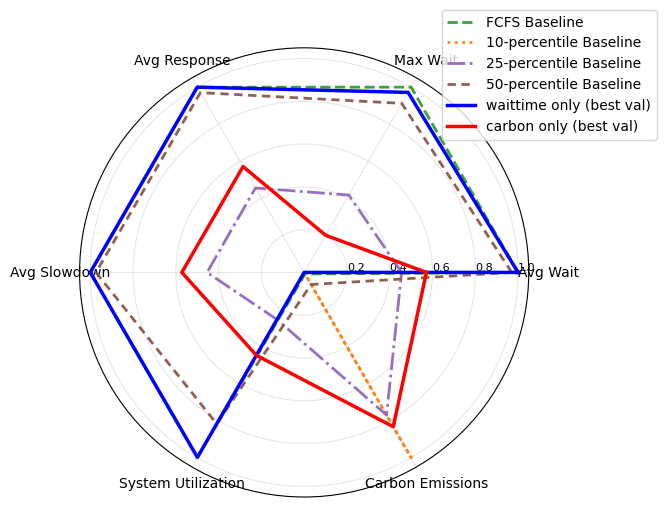

In [23]:
plot_scheduler_radar(batch_baselines_val_results)

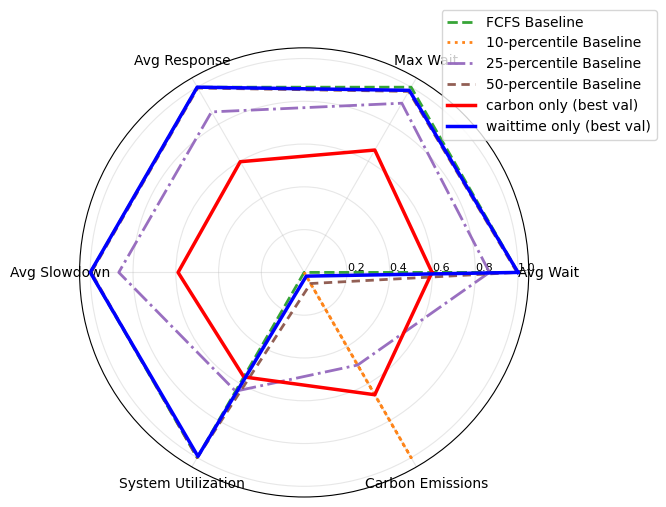

In [24]:
plot_scheduler_radar(test_results)

## Workload  statistics

In [7]:
def create_job_df(path):
    rows = []
    with open(path) as fp:
        for line in fp:
            if line.startswith(";"):
                continue
            line = line.strip()
            s_array = re.split(r"\s+", line)
            
            # Append to standard Python lists
            submit_time = int(s_array[1])
            req_processors = int(s_array[4])
            req_run_time = int(s_array[3])

            rows.append({"submit_time": submit_time, "requested_processors": req_processors, "requested_runtime": req_run_time})

    return pd.DataFrame(rows);

def plot_workload_patterns(
    df: pd.DataFrame,
    origin="2021-01-01",
    time_unit="s",                 # "s" if submit_time is in seconds; use "ms" if milliseconds, etc.
    runtime_bins_hours=None,       # custom edges in HOURS; leave None to use fine short bins below
    runtime_clip_q=None            # e.g., 0.995 to clip long tail before binning; or None
):
    need = {"submit_time", "requested_runtime", "requested_processors"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    df = df.copy()
    df["submit_time"] = pd.to_numeric(df["submit_time"], errors="coerce")
    df["requested_runtime"] = pd.to_numeric(df["requested_runtime"], errors="coerce")
    df["requested_processors"] = pd.to_numeric(df["requested_processors"], errors="coerce")
    df = df.dropna(subset=["submit_time"])
    df = df[df["submit_time"] >= 0]

    # Build timestamps from submit_time
    t0 = pd.to_datetime(origin)
    df["timestamp"] = t0 + pd.to_timedelta(df["submit_time"], unit=time_unit)
    df["hour"] = df["timestamp"].dt.hour

    # ---------- Weekly job submissions (avg per weekday) ----------
    per_day = df.set_index("timestamp").resample("D").size().rename("count")
    weekly_avg = (
        per_day.groupby(per_day.index.weekday).mean().reindex(range(7), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekly_avg.values)
    plt.xlabel("Day of week"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Monthly job submissions (avg per day, Jan..Dec across all years) ----------
    # Use resampled daily series so months without submissions still contribute 0 days.
    monthly_avg_per_day = (
        per_day.groupby(per_day.index.month)   # 1..12 across all years
        .mean()
        .reindex(range(1,13), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            monthly_avg_per_day.values)
    plt.xlabel("Month"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Hour-of-day submission pattern (percentage) ----------
    hour_pct = (
        df["hour"].value_counts(normalize=True)
        .reindex(range(24), fill_value=0.0)
        .sort_index() * 100.0
    )
    plt.figure()
    plt.bar(range(24), hour_pct.values)
    plt.xlabel("Hour of day"); plt.ylabel("Percentage of submissions")
    plt.xticks(range(24))
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Job size distribution (processors) ----------
    sizes = df["requested_processors"].dropna()
    sizes = sizes[sizes > 0]
    size_bins = [1, 4, 8, 32, 128, 256, np.inf]
    size_labels = ["1-4", "4-8", "8-32", "32-128", "128-256", "256"]
    cat = pd.cut(sizes, size_bins, right=False, include_lowest=True, labels=size_labels)
    dist_pct = (cat.value_counts().sort_index() / len(sizes)) * 100.0
    plt.figure()
    plt.bar(dist_pct.index.astype(str), dist_pct.values)
    plt.xlabel("Job size bins"); plt.ylabel("Percentage")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Distribution of requested runtimes (hours) — fine short bins ----------
    rt_h = (df["requested_runtime"].dropna() / 3600.0)
    rt_h = rt_h[rt_h > 0]
    if len(rt_h) == 0:
        plt.figure(); plt.title("Distribution of requested runtimes (hours)")
        plt.text(0.5, 0.5, "No positive runtimes", ha="center"); plt.axis("off"); plt.show()
        return

    if runtime_clip_q:
        rt_h = rt_h.clip(upper=float(rt_h.quantile(runtime_clip_q)))

    # Default: extra-fine bins at short end (minutes), then hour bins
    if runtime_bins_hours is None:
        mins = np.array([0,1, 2, 5, 10, 15, 20, 30, 45, 60]) / 60.0
        hrs  = np.array([2, 4, 8, 12, 24, 48, np.inf], dtype=float)
        runtime_bins_hours = np.concatenate([mins, hrs])

    counts, edges = np.histogram(rt_h.values, bins=runtime_bins_hours)
    pct = counts / counts.sum() * 100.0

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    labels = []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        if np.isinf(hi):
            labels.append(f"{fmt_h(lo)}+")
        else:
            labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    plt.figure()
    plt.bar(labels, pct)
    plt.xlabel("Requested runtime bins"); plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

#### COmparison of different traces

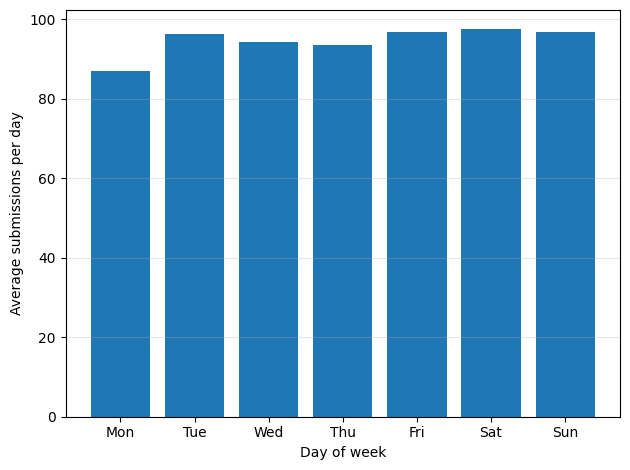

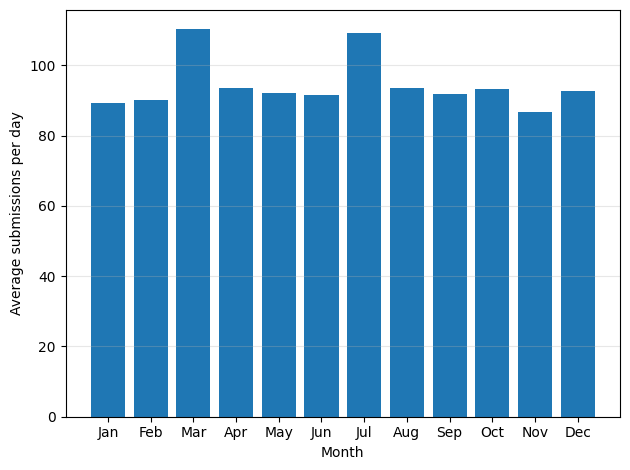

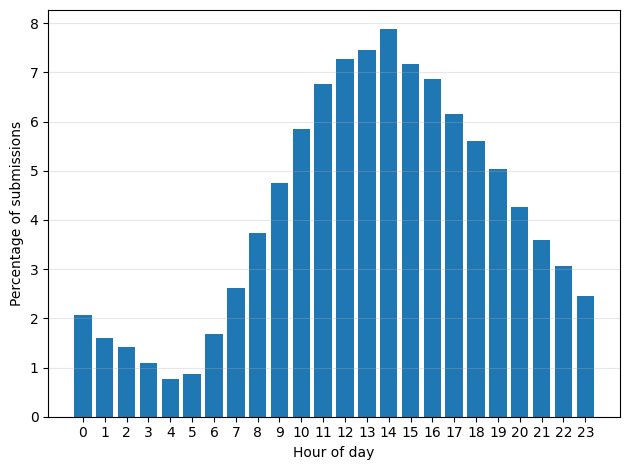

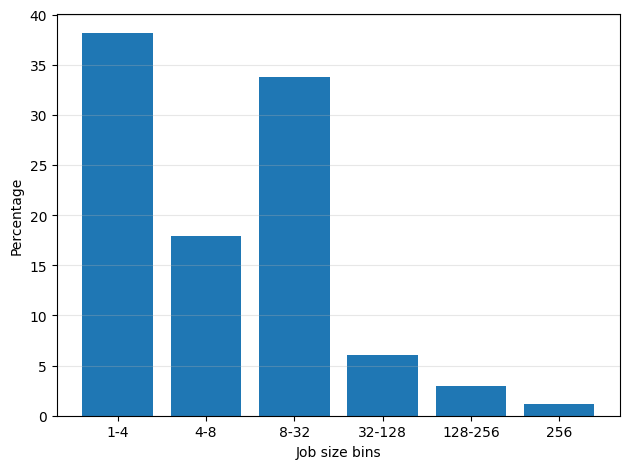

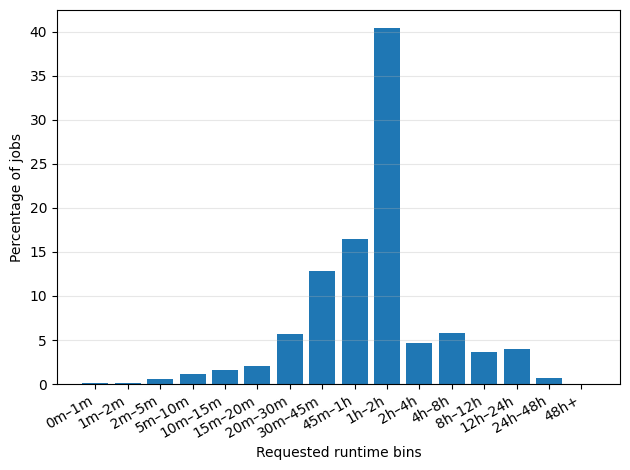

,submit_time,requested_processors,requested_runtime
0,244,2,4196
1,1193,256,75654
2,3170,2,4611
3,3557,8,3355
4,4024,4,3455


In [11]:
# Non convergent dataset:
alternative = "scripts/workload.swf"
df_batch = create_job_df(path=alternative)
plot_workload_patterns(df_batch)
df_batch.head()

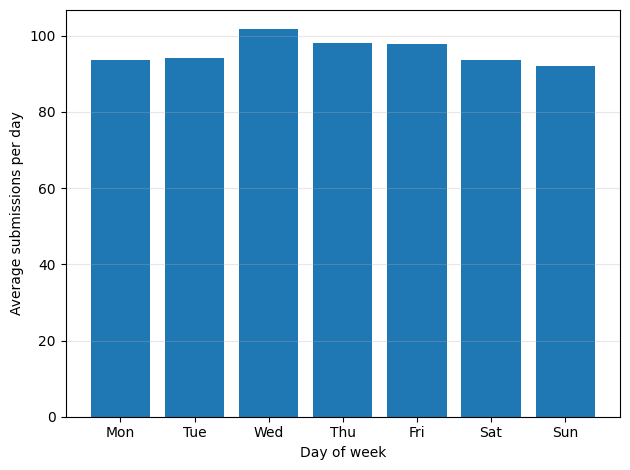

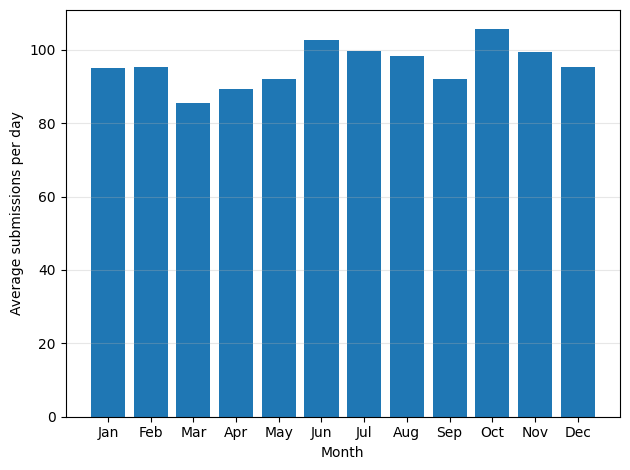

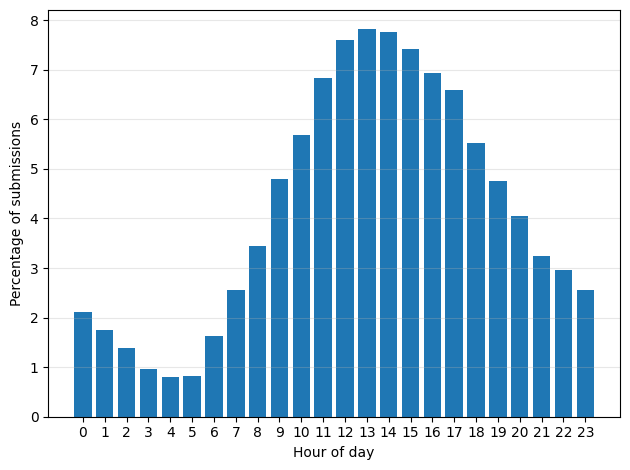

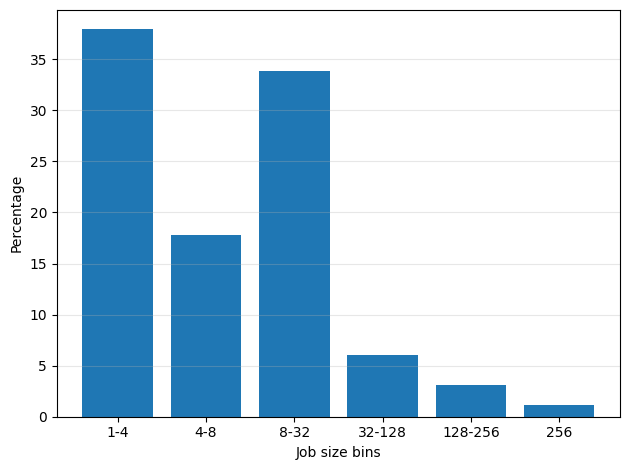

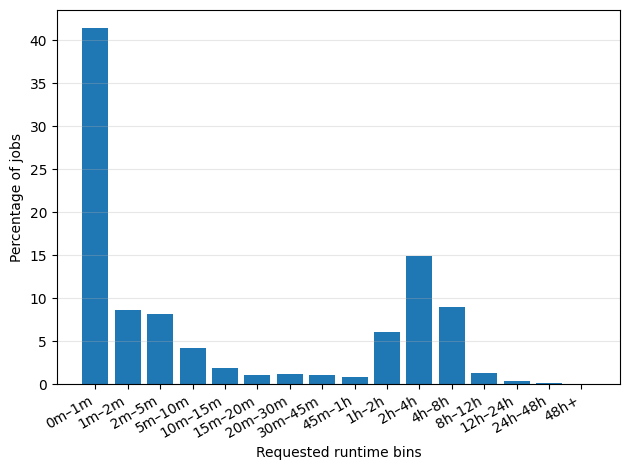

,submit_time,requested_processors,requested_runtime
0,266,14,25461
1,366,16,6930
2,1352,32,23151
3,1393,6,54
4,1856,6,105


In [8]:
# Non convergent dataset:
WORKLOAD_PATH_BAD = "data/workloads/batch/training_workload.swf"
df_batch = create_job_df(path=WORKLOAD_PATH_BAD)
plot_workload_patterns(df_batch)
df_batch.head()


In [9]:


df_batch["compute_time"] = df_batch["requested_processors"] * df_batch["requested_runtime"]

# empirical mean/std (sample std by default with ddof=1)
mu = df_batch["compute_time"].mean()
sigma = df_batch["compute_time"].std(ddof=1)

print("mu", mu)
print("sigma,", sigma)

mu 143567.71930292607
sigma, 587102.0877243354


In [10]:

def plot_runtime_size_heatmap(df, size_bins=None, normalize=True, cmap="magma"):
    """
    Heatmap of job distribution across runtime bins and processor size bins.
    Uses the same runtime bins as in plot_workload_patterns.
    """

    df = df.copy()

    # Runtime bins (same as your earlier function, converted to seconds)
    mins = np.array([0,1,2,5,10,15,20,30,45,60]) / 60.0   # hours → fractional hours
    hrs  = np.array([2, 4, 8, 12, 24, 48, np.inf], dtype=float)
    runtime_bins_hours = np.concatenate([mins, hrs])
    runtime_bins_seconds = runtime_bins_hours * 3600

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    runtime_labels = []
    for i in range(len(runtime_bins_hours)-1):
        lo, hi = runtime_bins_hours[i], runtime_bins_hours[i+1]
        if np.isinf(hi):
            runtime_labels.append(f"{fmt_h(lo)}+")
        else:
            runtime_labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    # Processor size bins (default if none provided)
    if size_bins is None:
        size_bins = [1, 4, 8, 32, 128, 256, np.inf]
    size_labels = [f"{size_bins[i]}–{size_bins[i+1]-1 if np.isfinite(size_bins[i+1]) else '+'}"
                   for i in range(len(size_bins)-1)]

    # Cut into bins
    df["runtime_bin"] = pd.cut(df["requested_runtime"], bins=runtime_bins_seconds, labels=runtime_labels, right=False)
    df["size_bin"] = pd.cut(df["requested_processors"], bins=size_bins,
                            labels=size_labels, right=False)

    # Cross-tabulate
    heatmap_data = pd.crosstab(df["size_bin"], df["runtime_bin"])

    if normalize:
        heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # percentage

    # Plot heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".1f",
                cmap=cmap, cbar_kws={"label": "Percentage" if normalize else "Count"})
    plt.xlabel("Runtime bins")
    plt.ylabel("Processor size bins")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



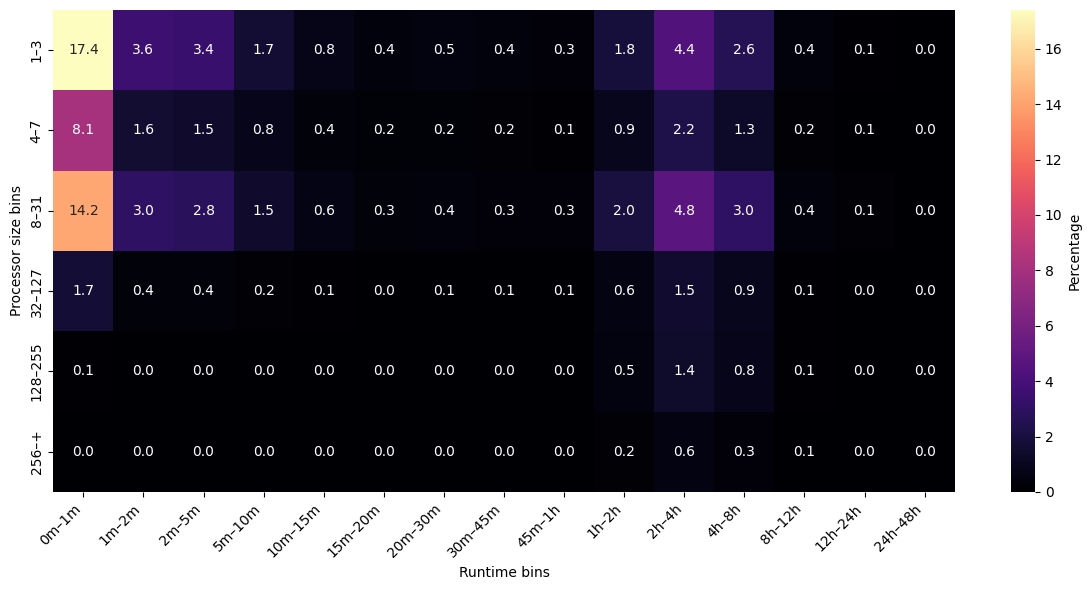

In [11]:
plot_runtime_size_heatmap(df_batch, normalize=True)

## Interactive workload

## Actual workload trace EXA

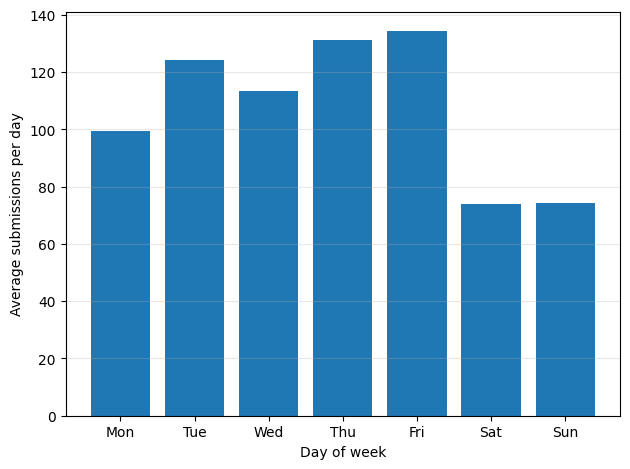

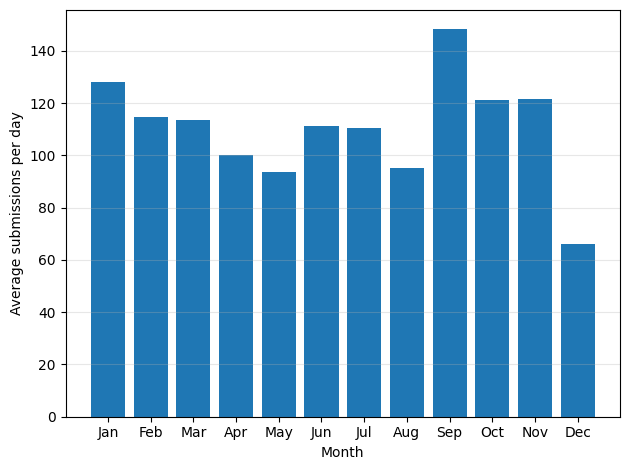

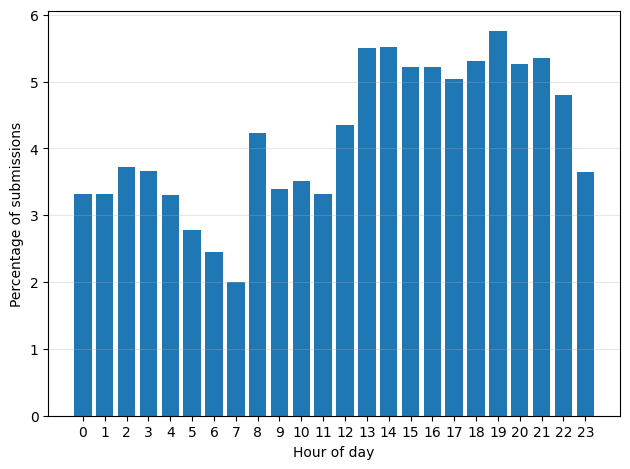

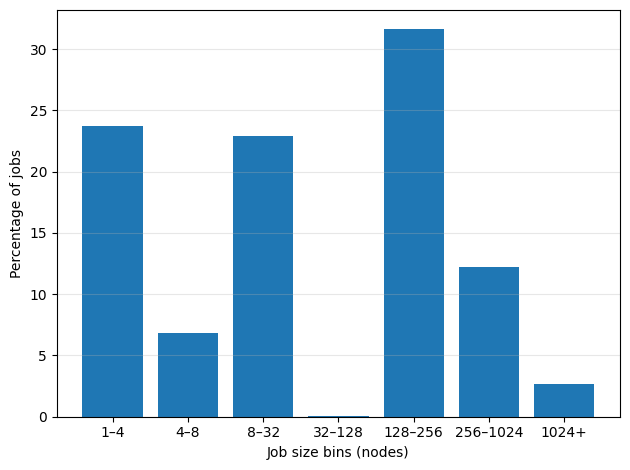

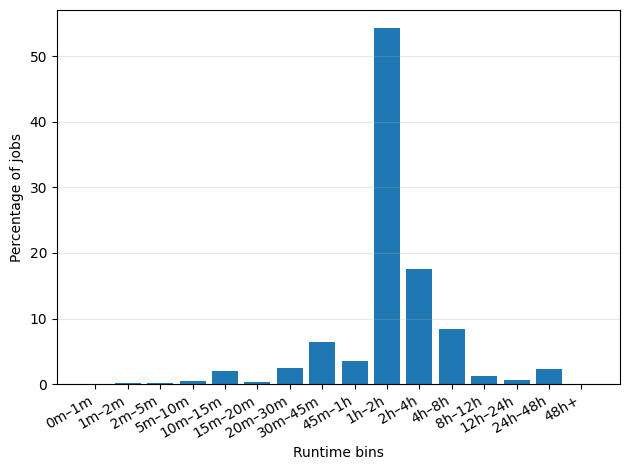

In [ ]:

# Path to your CSV file
csv_path = "data/ANL-ALCF-DJC-THETA_20230101_20231231.csv"

# Read the CSV
df_raw = pd.read_csv(csv_path)

# Select only the relevant columns and rename them
df = df_raw[["QUEUED_TIMESTAMP", "NODES_REQUESTED", "WALLTIME_SECONDS"]].rename(
    columns={
        "QUEUED_TIMESTAMP": "submit_time",
        "NODES_REQUESTED": "requested_nodes",
        "WALLTIME_SECONDS": "runtime"
    }
)


def plot_csv_job_patterns(
    df: pd.DataFrame,
    runtime_bins_hours=None,
    runtime_clip_q=None
):
    """
    Create workload-like plots from CSV job data with columns:
      submit_time (datetime64), requested_nodes (int), runtime (seconds)
    """

    need = {"submit_time", "requested_nodes", "runtime"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    # Ensure correct types
    df = df.copy()
    df["submit_time"] = pd.to_datetime(df["submit_time"], errors="coerce")
    df["requested_nodes"] = pd.to_numeric(df["requested_nodes"], errors="coerce")
    df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")

    df = df.dropna(subset=["submit_time"])
    df = df[df["submit_time"] >= pd.Timestamp("1970-01-01")]

    # Extract hour-of-day
    df["hour"] = df["submit_time"].dt.hour

    # ---------- Weekly job submissions (avg per weekday) ----------
    per_day = df.set_index("submit_time").resample("D").size().rename("count")
    weekly_avg = (
        per_day.groupby(per_day.index.weekday).mean().reindex(range(7), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekly_avg.values)
    plt.xlabel("Day of week"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Monthly job submissions (avg per day) ----------
    monthly_avg_per_day = (
        per_day.groupby(per_day.index.month)
        .mean()
        .reindex(range(1,13), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            monthly_avg_per_day.values)
    plt.xlabel("Month"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Hour-of-day submission pattern ----------
    hour_pct = (
        df["hour"].value_counts(normalize=True)
        .reindex(range(24), fill_value=0.0)
        .sort_index() * 100.0
    )
    plt.figure()
    plt.bar(range(24), hour_pct.values)
    plt.xlabel("Hour of day"); plt.ylabel("Percentage of submissions")
    plt.xticks(range(24))
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Job size distribution (requested_nodes) ----------
    sizes = df["requested_nodes"].dropna()
    sizes = sizes[sizes > 0]
    size_bins = [1, 4, 8, 32, 128, 256, 1024, np.inf]
    size_labels = ["1–4", "4–8", "8–32", "32–128", "128–256", "256–1024", "1024+"]
    cat = pd.cut(sizes, size_bins, right=False, include_lowest=True, labels=size_labels)
    dist_pct = (cat.value_counts().sort_index() / len(sizes)) * 100.0
    plt.figure()
    plt.bar(dist_pct.index.astype(str), dist_pct.values)
    plt.xlabel("Job size bins (nodes)"); plt.ylabel("Percentage of jobs")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Distribution of runtimes (hours) ----------
    rt_h = df["runtime"].dropna() / 3600.0
    rt_h = rt_h[rt_h > 0]
    if len(rt_h) == 0:
        plt.figure(); plt.title("Distribution of runtimes (hours)")
        plt.text(0.5, 0.5, "No positive runtimes", ha="center"); plt.axis("off"); plt.show()
        return

    if runtime_clip_q:
        rt_h = rt_h.clip(upper=float(rt_h.quantile(runtime_clip_q)))

    if runtime_bins_hours is None:
        mins = np.array([0,1,2,5,10,15,20,30,45,60]) / 60.0
        hrs  = np.array([2,4,8,12,24,48,np.inf], dtype=float)
        runtime_bins_hours = np.concatenate([mins, hrs])

    counts, edges = np.histogram(rt_h.values, bins=runtime_bins_hours)
    pct = counts / counts.sum() * 100.0

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    labels = []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        if np.isinf(hi):
            labels.append(f"{fmt_h(lo)}+")
        else:
            labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    plt.figure()
    plt.bar(labels, pct)
    plt.xlabel("Runtime bins"); plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

plot_csv_job_patterns(df)

## Carbon intensity statistics

In [1]:
# --- imports (ensure these are present) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def read_carbon_csv(path: str) -> pd.DataFrame:
    """
    Reads the CSV and returns a dataframe with columns:
    - timestamp (UTC-aware pandas datetime)
    - value (float)
    """
    df = pd.read_csv(path, parse_dates=[0])
    df.columns = [c.strip() for c in df.columns]

    ts_col = df.columns[0]
    candidate_value_cols = [c for c in df.columns[1:]
                            if c.strip().lower() in ("value", "carbon intensity",
                                                     "carbon_intensity", "intensity")]
    value_col = candidate_value_cols[0] if candidate_value_cols else df.columns[1]

    df = df.rename(columns={ts_col: "timestamp", value_col: "value"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    df = df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)
    return df


def plot_profile_with_std(x, mean_series, std_series, x_tick_labels, x_label, y_label, outfile):
    """
    Plots mean line with a grey ±1 std band. No title.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    mean_vals = np.asarray(mean_series.values, dtype=float)
    std_vals = np.asarray(std_series.fillna(0).values, dtype=float)
    lower = mean_vals - std_vals
    upper = mean_vals + std_vals

    x = np.asarray(x)
    valid = ~np.isnan(mean_vals)

    ax.plot(x[valid], mean_vals[valid], linewidth=2, label="Mean", color="black")
    ax.fill_between(x[valid], lower[valid], upper[valid], alpha=0.25, label="±1 SD", color="gray")

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle="--", alpha=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation=0)
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    plt.close(fig)


path = "data/DK-DK2_minutely_carbon_intensity_improved.csv"
df = read_carbon_csv(path)

# DAILY PROFILE (by hour 0..23)
by_hour = (
    df.groupby(df["timestamp"].dt.hour)["value"]
      .agg(mean="mean", std="std")
      .reindex(range(24))
)
hours = np.arange(24)
hour_labels = [f"{h:02d}" for h in hours]
plot_profile_with_std(
    x=hours,
    mean_series=by_hour["mean"],
    std_series=by_hour["std"],
    x_tick_labels=hour_labels,
    x_label="Hour of Day (00–23, UTC)",
    y_label="Carbon Intensity",
    outfile="daily_profile.png",
)

# WEEKLY PROFILE (by weekday Mon..Sun; Monday=0)
weekday_order = list(range(7))
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = (
    df.groupby(df["timestamp"].dt.dayofweek)["value"]
      .agg(mean="mean", std="std")
      .reindex(weekday_order)
)
plot_profile_with_std(
    x=weekday_order,
    mean_series=by_weekday["mean"],
    std_series=by_weekday["std"],
    x_tick_labels=weekday_names,
    x_label="Weekday",
    y_label="Carbon Intensity",
    outfile="weekly_profile.png",
)

# --- NEW 1: MONTH-OF-YEAR PROFILE (Jan..Dec across all years) ---
month_order = list(range(1, 13))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
by_month = (
    df.groupby(df["timestamp"].dt.month)["value"]
      .agg(mean="mean", std="std")
      .reindex(month_order)
)
plot_profile_with_std(
    x=month_order,
    mean_series=by_month["mean"],
    std_series=by_month["std"],
    x_tick_labels=month_names,
    x_label="Month",
    y_label="Carbon Intensity",
    outfile="monthly_profile.png",
)

# --- NEW 2: CALENDAR-MONTH TREND (YYYY-MM over time) ---
# Mean and within-month std for each calendar month start (MS = month start)
monthly_trend = (
    df.set_index("timestamp")["value"]
      .resample("MS")
      .agg(mean="mean", std="std")
)
# Use integer x with YYYY-MM labels to fit the plotting utility
m_idx = np.arange(len(monthly_trend))
m_labels = [ts.strftime("%Y-%m") for ts in monthly_trend.index]
plot_profile_with_std(
    x=m_idx,
    mean_series=monthly_trend["mean"],
    std_series=monthly_trend["std"],
    x_tick_labels=m_labels,
    x_label="Calendar Month (YYYY–MM)",
    y_label="Carbon Intensity",
    outfile="monthly_trend.png",
)

# YEARLY PROFILE (by calendar year)
by_year = (
    df.groupby(df["timestamp"].dt.year)["value"]
      .agg(mean="mean", std="std")
      .sort_index()
)
years = by_year.index.to_numpy()
year_labels = [str(y) for y in years]
plot_profile_with_std(
    x=years,
    mean_series=by_year["mean"],
    std_series=by_year["std"],
    x_tick_labels=year_labels,
    x_label="Year",
    y_label="Carbon Intensity",
    outfile="yearly_profile.png",
)

print("Saved: daily_profile.png, weekly_profile.png, monthly_profile.png, monthly_trend.png, yearly_profile.png")


Saved: daily_profile.png, weekly_profile.png, monthly_profile.png, monthly_trend.png, yearly_profile.png


In [ ]:
import sys
import pandas as pd

def compute_percentiles(csv_path):
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Make sure Value column exists
    if "Value" not in df.columns:
        raise ValueError("CSV must contain a 'Value' column")
    
    # Convert Value column to numeric (force errors to NaN and drop them)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df.dropna(subset=["Value"])
    
    # Compute percentiles
    percentiles = df["Value"].quantile([0.10, 0.25, 0.50])
    
    print("Percentiles for 'Value':")
    for p, val in percentiles.items():
        print(f"{int(p*100)}th percentile: {val:.4f}")

compute_percentiles("data/DK-DK2_minutely_carbon_intensity_improved.csv")

/var/folders/9h/bnhs_81n0933zyrnm6nwdg8w0000gn/T/ipykernel_49488/158549358.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Percentiles for 'Value':
10th percentile: 31.9240
25th percentile: 47.3247
50th percentile: 78.4003


# Eta results:

#### Systemwide

In [14]:
def plot_baselines_and_results(
    additional_results=None,
    annotate=("FCFS","50-percentile", "80-percentile", "95-percentile"),
    include_fcfs=False,
    connect_baselines=False,
    show_title=False,
):
    """
    Plot Avg Wait (x) vs Carbon Emissions (y) for baselines (25–97 percentiles),
    and overlay optional additional results (single points OR mean±std).

    Parameters
    ----------
    additional_results : list[dict] | None
        Each dict may be ONE of:
          - {"label": str, "wait_mean": float, "wait_std": float,
             "carbon_mean": float, "carbon_std": float}
            -> plots mean with error bars (std) on both axes
          - {"label": str, "wait": float, "carbon": float}
            -> plots a single point
    annotate : iterable[str]
        Baseline names to annotate to avoid clutter.
    include_fcfs : bool
        If True, also plots FCFS baseline as a single point.
    connect_baselines : bool
        If True, draws a line connecting baseline points (sorted by Avg Wait).
    show_title : bool
        If True, adds a small title.

    Returns
    -------
    (fig, ax) : Matplotlib Figure and Axes
    """
    # ----------------------
    # Baselines (Test Phase), 25–97 percentiles (10th removed)
    # ----------------------
    baselines = [
 ##       {"name": "25-percentile", "avg_wait": 7_270_935.09, "carbon": 56_814_996.31},
        {"name": "50-percentile", "avg_wait":   490_242.82, "carbon": 60_417_140.50},
        {"name": "60-percentile", "avg_wait":   168_947.01, "carbon": 62_965_396.88},
        {"name": "70-percentile", "avg_wait":    91_163.42, "carbon": 64_188_644.12},
        {"name": "80-percentile", "avg_wait":    36_792.31, "carbon": 64_881_421.46},
        {"name": "90-percentile", "avg_wait":    21_163.81, "carbon": 64_333_117.64},
        {"name": "95-percentile", "avg_wait":    17_026.93, "carbon": 64_185_133.46},
    ]
    if include_fcfs:
        baselines.append({"name": "FCFS", "avg_wait": 12_386.08, "carbon": 64_247_149.32})

    xs = [b["avg_wait"] for b in baselines]
    ys = [b["carbon"] for b in baselines]

    fig, ax = plt.subplots()

    # Baseline scatter
    ax.scatter(xs, ys, label="Baselines (25–97 pct.)")

    # Optional connecting line (sorted by wait)
    if connect_baselines:
        order = sorted(range(len(xs)), key=lambda i: xs[i])
        ax.plot([xs[i] for i in order], [ys[i] for i in order])

    # Annotate selected baselines
    for b in baselines:
        if b["name"] in annotate:
            ax.annotate(
                b["name"],
                (b["avg_wait"], b["carbon"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    # Overlay additional results
    all_x = xs[:]
    all_y = ys[:]
    if additional_results:
        for r in additional_results:
            label = r.get("label", "Result")
            if "wait_mean" in r and "carbon_mean" in r:
                x = float(r["wait_mean"])
                y = float(r["carbon_mean"])
                xerr = float(r.get("wait_std", 0.0)) if r.get("wait_std") is not None else None
                yerr = float(r.get("carbon_std", 0.0)) if r.get("carbon_std") is not None else None
                ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o", capsize=5, label=label)
                all_x.append(x); all_y.append(y)
            elif "wait" in r and "carbon" in r:
                x = float(r["wait"]); y = float(r["carbon"])
                ax.scatter([x], [y], label=label)
                all_x.append(x); all_y.append(y)

    # Labels (no title by default)
    ax.set_xlabel("Average Wait")
    ax.set_ylabel("Carbon Emissions")
    if show_title:
        ax.set_title("Avg Wait vs Carbon Emissions")


    ax.set_xscale("log", base=10)
    ax.grid(True, which="both")
    ax.legend()
    fig.tight_layout()
    return fig, ax


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Average Wait', ylabel='Carbon Emissions'>)

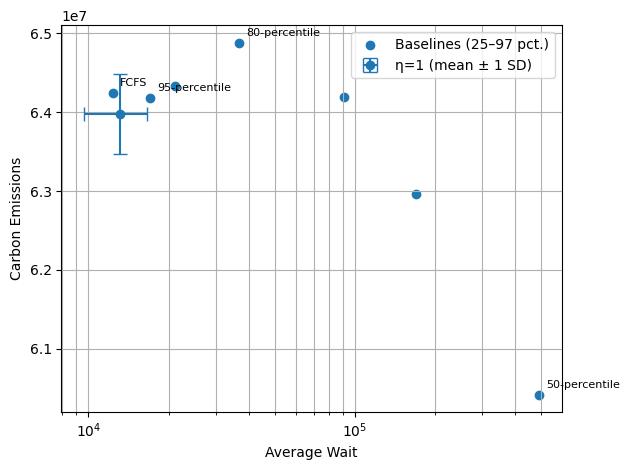

In [15]:
results_eta_1_dense = {
        "label": "η=1 (mean ± 1 SD)",
        "wait_mean": 13_142,
        "wait_std": 3_495,
        "carbon_mean": 63_977_561,
        "carbon_std": 502_669,
}

plot_baselines_and_results([results_eta_1_dense], include_fcfs=True)